Mengimport semua Library

In [2]:
import requests
import csv
import time
import urllib.parse

Proses mengambil ulsn berdasarkan App ID dari game di Steam


In [ ]:
def get_steam_reviews(app_id, limit=None):
    all_reviews = []
    cursor = '*'
    url_template = "https://store.steampowered.com/appreviews/{app_id}?json=1&filter=all&language=all&review_type=all&purchase_type=all&cursor={cursor}"

    print(f"Memulai pengambilan ulasan untuk App ID: {app_id}...")

    while True:
        encoded_cursor = urllib.parse.quote(cursor)
        url = url_template.format(app_id=app_id, cursor=encoded_cursor)

        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            data = response.json()
        except requests.exceptions.RequestException as e:
            print(f"Error saat melakukan request: {e}")
            break
        except ValueError:
            print("Gagal mem-parsing JSON. Mungkin ada masalah dengan respons dari Steam.")
            break

        if data.get('success') != 1:
            print(f"API request gagal. Pesan dari Steam: {data.get('success')}")
            break

        reviews = data.get('reviews', [])
        if not reviews:
            print("Tidak ada ulasan lagi yang ditemukan.")
            break

        for review in reviews:
            all_reviews.append(review)
        num_fetched = len(reviews)
        total_reviews_so_far = len(all_reviews)
        print(f"Berhasil mengambil {num_fetched} ulasan. Total ulasan sejauh ini: {total_reviews_so_far}")

        if limit is not None and total_reviews_so_far >= limit:
            print(f"Batas {limit} ulasan telah tercapai.")
            return all_reviews[:limit]

        next_cursor = data.get('cursor')
        if not next_cursor or next_cursor == cursor:
            print("Telah mencapai akhir dari semua ulasan.")
            break
        
        cursor = next_cursor
        time.sleep(1)

    return all_reviews

Menggolongkan kategori apa saja yang diambil

In [ ]:
def save_reviews_to_csv(reviews, filename="steam_reviews.csv"):
    if not reviews:
        print("Tidak ada ulasan untuk disimpan.")
        return

    fieldnames = [
        'recommendationid',
        'author_steamid',
        'author_num_games_owned',
        'author_num_reviews',
        'author_playtime_forever',
        'author_playtime_last_two_weeks',
        'language',
        'review',
        'timestamp_created',
        'timestamp_updated',
        'voted_up',
        'votes_up',
        'votes_funny',
        'weighted_vote_score',
        'steam_purchase',
        'received_for_free'
    ]
    print(f"\nMenyimpan {len(reviews)} ulasan ke dalam file '{filename}'...")

    try:
        with open(filename, mode='w', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)

            writer.writerow(fieldnames)

            for review in reviews:
                author_info = review.get('author', {})
                row = [
                    review.get('recommendationid'),
                    author_info.get('steamid'),
                    author_info.get('num_games_owned'),
                    author_info.get('num_reviews'),
                    author_info.get('playtime_forever'),
                    author_info.get('playtime_last_two_weeks'),
                    review.get('language'),
                    review.get('review').replace('\n', ' ').replace('\r', ''),
                    review.get('timestamp_created'),
                    review.get('timestamp_updated'),
                    review.get('voted_up'),
                    review.get('votes_up'),
                    review.get('votes_funny'),
                    review.get('weighted_vote_score'),
                    review.get('steam_purchase'),
                    review.get('received_for_free')
                ]
                writer.writerow(row)
        print("Proses penyimpanan selesai!")
    except IOError as e:
        print(f"Error saat menulis ke file: {e}")

Mengeksekusi proses yang telah dilakukan di atas lalu menyimpan hasil nya dalam bentuk csv

In [5]:
if __name__ == "__main__":
    APP_ID = 2124490  
    REVIEW_LIMIT = 5000

    all_game_reviews = get_steam_reviews(APP_ID, limit=REVIEW_LIMIT)

    if all_game_reviews:
        output_filename = f"steam_reviews_2_{APP_ID}.csv"
        save_reviews_to_csv(all_game_reviews, filename=output_filename)


Memulai pengambilan ulasan untuk App ID: 2124490...
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 20
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 40
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 60
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 80
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 100
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 120
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 140
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 160
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 180
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 200
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 220
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 240
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 260
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 280
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 300
Berhasil mengambil 20 ulasan. Total ulasan sejauh ini: 320
Berhasil

menampilkan tabel.

In [6]:
import pandas as pd

df = pd.read_csv('steam_reviews_2_2124490.csv')
df.info()
print(df.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   recommendationid                5000 non-null   int64  
 1   author_steamid                  5000 non-null   int64  
 2   author_num_games_owned          5000 non-null   int64  
 3   author_num_reviews              5000 non-null   int64  
 4   author_playtime_forever         5000 non-null   int64  
 5   author_playtime_last_two_weeks  5000 non-null   int64  
 6   language                        5000 non-null   object 
 7   review                          4994 non-null   object 
 8   timestamp_created               5000 non-null   int64  
 9   timestamp_updated               5000 non-null   int64  
 10  voted_up                        5000 non-null   bool   
 11  votes_up                        5000 non-null   int64  
 12  votes_funny                     50

Menginstall dan  melakukan import dari library nltk.

In [16]:
import nltk
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')
try:
    word_tokenize("test")
except LookupError:
    nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\renka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\renka\AppData\Roaming\nltk_data...


Melakukan deteksi bahasa dan mengambil bahasa inggris menjadi bahasa utama yang akan digunakan.

In [12]:
import pandas as pd
from langdetect import detect, LangDetectException

review_column = df["review"]

df["review"] = df["review"].fillna('').astype(str)

def safe_detect_language(text):
    if text.strip() == "":
        return 'empty'
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'
    except Exception:
        return 'error'

print("Mulai deteksi bahasa...")
df['language'] = df["review"].apply(safe_detect_language)
print("Deteksi bahasa selesai.")

df_english = df[df['language'] == 'en'].copy()

print("\n--- Ringkasan Hasil ---")
print(f"Total Review: {len(df)}")
print(f"Jumlah Review Berbahasa Inggris ('en'): {len(df_english)}")
print(f"10 Bahasa Teratas Ditemukan:\n{df['language'].value_counts().head(10)}")

print("\n5 Review Berbahasa Inggris Pertama:")
print(df_english[["review", 'language']].head())

steam_original_english = df_english["review"]
print("\nVariabel steam_original_english telah diperbarui dengan review bahasa Inggris saja.")

Mulai deteksi bahasa...
Deteksi bahasa selesai.

--- Ringkasan Hasil ---
Total Review: 5000
Jumlah Review Berbahasa Inggris ('en'): 2345
10 Bahasa Teratas Ditemukan:
language
en         2345
ru          396
es          328
zh-cn       267
pt          147
ko          131
unknown     125
de          118
so          118
fr          117
Name: count, dtype: int64

5 Review Berbahasa Inggris Pertama:
                                               review language
1   i rarely leave reviews, but this one deserves ...       en
2   It's the town I name ALL my towns after when a...       en
4   Dog ending is canon.   ... No, but seriously. ...       en
10  10/10 , an absolute masterpiece!  Atmosphere ,...       en
13  One of my favorite horror games, both this one...       en

Variabel steam_original_english telah diperbarui dengan review bahasa Inggris saja.


In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words_en = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_english_text(text):
    # 1. Cleaning: Hapus URL, tag HTML (jika ada), dan karakter non-alfabet
    # Hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Hapus tag HTML (jika ada sisa dari scraping)
    text = re.sub(r'<.*?>', '', text)
    # Hapus karakter non-alfabet (angka, tanda baca)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 2. Case Folding
    text = text.lower()

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Stopword Removal & 5. Lemmatization
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words_en:
            lemma_word = lemmatizer.lemmatize(word)
            cleaned_tokens.append(lemma_word)

    return " ".join(cleaned_tokens)

print("Fungsi preprocess_english_text() telah dibuat.")

Fungsi preprocess_english_text() telah dibuat.


In [ ]:
print("Memulai preprocessing pada review bahasa Inggris...")

# Terapkan fungsi ke kolom "review" di df_english
df_english['review_cleaned'] = df_english['review'].apply(preprocess_english_text)

print("Preprocessing selesai.")

print("\n--- Perbandingan Review Asli vs Cleaned (5 Teratas) ---")
for i in range(5):
    print(f"\nReview Asli #{i+1}:")
    print(df_english['review'].iloc[i])
    print("\nReview Cleaned:")
    print(df_english['review_cleaned'].iloc[i])
    print("-" * 20)

steam_cleaned_english = df_english['review_cleaned']
print("\nVariabel steam_cleaned_english telah dibuat dengan data bersih.")

Memulai preprocessing pada review bahasa Inggris...
Preprocessing selesai.

--- Perbandingan Review Asli vs Cleaned (5 Teratas) ---

Review Asli #1:
i rarely leave reviews, but this one deserves it. a truly moving experience that just gripped me, wrapped in unsettling, heavy atmosphere, sound, and themes. it’s far more than just fog and monsters—it’s a journey into the darkest corners of humanity.

Review Cleaned:
rarely leave review one deserves truly moving experience gripped wrapped unsettling heavy atmosphere sound theme far fog monstersits journey darkest corner humanity
--------------------

Review Asli #2:
It's the town I name ALL my towns after when a game lets you name a city/farm/town. A true legacy here! Beautiful, subtle horror, my favorite kind. This game put me on the path to horror I liked verses horror I did not. Silent Hill teaches you about yourself! I had such a creeping sense of dread while playing.. I could not wait to get to the next bit with a PERSON, and the gam

In [ ]:
# 1. Normalisasi Kata
print("Memulai Normalisasi Kata...")

normalization_dict = {
    "u": "you",
    "r": "are",
    "ur": "your",
    "im": "i am",
    "i'm": "i am",
    "ive": "i have",
    "i've": "i have",
    "dont": "do not",
    "don't": "do not",
    "cant": "cannot",
    "can't": "cannot",
    "wont": "will not",
    "won't": "will not",
    "gr8": "great",
    "b4": "before",
    "thx": "thanks",
    "lol": "laughing out loud"
}

def normalize_text(text):
    words = text.split()
    normalized_words = []
    
    for word in words:
        normalized_word = normalization_dict.get(word, word)
        normalized_words.append(normalized_word)
        
    return " ".join(normalized_words)

df_english['review_normalized'] = df_english['review_cleaned'].apply(normalize_text)

print("Normalisasi Kata selesai.")
print("\n--- Contoh Hasil Normalisasi ---")
print("Teks Asli (cleaned):", df_english['review_cleaned'].iloc[0])
print("Teks Normalisasi:", df_english['review_normalized'].iloc[0])

Memulai Normalisasi Kata...
Normalisasi Kata selesai.

--- Contoh Hasil Normalisasi ---
Teks Asli (cleaned): rarely leave review one deserves truly moving experience gripped wrapped unsettling heavy atmosphere sound theme far fog monstersits journey darkest corner humanity
Teks Normalisasi: rarely leave review one deserves truly moving experience gripped wrapped unsettling heavy atmosphere sound theme far fog monstersits journey darkest corner humanity


In [ ]:
# 2. Hapus Duplikat
print("\nMemulai Penghapusan Duplikat...")

rows_before = len(df_english)
print(f"Jumlah baris sebelum duplikat dihapus: {rows_before}")

df_english.drop_duplicates(subset=['review_normalized'], keep='first', inplace=True)

rows_after = len(df_english)
print(f"Jumlah baris setelah duplikat dihapus: {rows_after}")
print(f"Total duplikat yang dihapus: {rows_before - rows_after}")

df_english.reset_index(drop=True, inplace=True)


Memulai Penghapusan Duplikat...
Jumlah baris sebelum duplikat dihapus: 2345
Jumlah baris setelah duplikat dihapus: 583
Total duplikat yang dihapus: 1762


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

print("\nMemulai Ekstraksi N-gram...")

corpus = df_english['review_normalized']

def get_top_ngrams(corpus, ngram_range, top_k=20):
    """
    Mengekstrak dan menghitung frekuensi N-gram.
    ngram_range adalah tuple, cth: (2, 2) untuk bi-gram, (3, 3) untuk tri-gram.
    """
    try:
        vec = CountVectorizer(ngram_range=ngram_range, stop_words='english')
        
        bag_of_words = vec.fit_transform(corpus)
        
        sum_words = bag_of_words.sum(axis=0)         
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]        
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
        
        return pd.DataFrame(words_freq[:top_k], columns=['Ngram', 'Frequency'])
        
    except ValueError as e:
        print(f"Error saat membuat N-gram {ngram_range}: {e}")
        print("Ini mungkin terjadi jika semua teks adalah stopwords atau kosong.")
        return pd.DataFrame(columns=['Ngram', 'Frequency'])

# --- Ekstrak Bi-gram (2 kata) ---
top_bigrams = get_top_ngrams(corpus, ngram_range=(2, 2), top_k=20)
print("\n--- 20 Bi-gram Teratas ---")
print(top_bigrams)

# --- Ekstrak Tri-gram (3 kata) ---
top_trigrams = get_top_ngrams(corpus, ngram_range=(3, 3), top_k=20)
print("\n--- 20 Tri-gram Teratas ---")
print(top_trigrams)


Memulai Ekstraksi N-gram...

--- 20 Bi-gram Teratas ---
              Ngram  Frequency
0       silent hill        215
1       horror game         96
2       game played         35
3   survival horror         34
4       hill remake         33
5         feel like         31
6      sound design         29
7        great game         28
8         game time         27
9      bloober team         25
10    original game         24
11  played original         24
12        best game         24
13        play game         20
14      best horror         20
15        love game         18
16   restless dream         18
17        hill game         17
18        game play         17
19      game really         16

--- 20 Tri-gram Teratas ---
                        Ngram  Frequency
0          silent hill remake         33
1            best horror game         20
2            silent hill game         17
3            town silent hill         14
4         restless dream town         14
5        survival


Membuat Word Cloud...
Menampilkan Word Cloud...


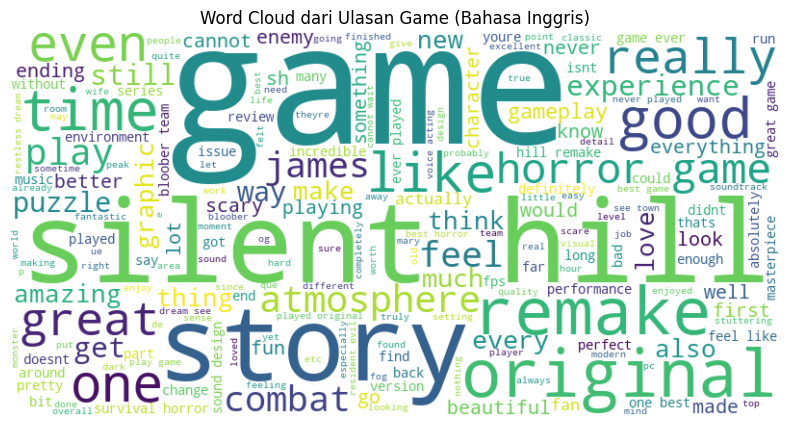


Seluruh proses selesai.


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

print("\nMembuat Word Cloud...")

all_text = " ".join(review for review in df_english['review_normalized'].dropna())

if all_text.strip() == "":
    print("Tidak ada teks untuk dibuatkan Word Cloud (mungkin semua data kosong).")
else:
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          stopwords=stopwords.words('english'),
                          min_font_size=10).generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud dari Ulasan Game (Bahasa Inggris)')
    # plt.savefig('steam_reviews_wordcloud.png') 
    
    print("Menampilkan Word Cloud...")
    plt.show()

print("\nSeluruh proses selesai.")

In [ ]:
import os

output_folder = "hasil_preprocessing"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Folder '{output_folder}' telah dibuat.")

file_path_main = os.path.join(output_folder, "steam_reviews_processed.csv")
try:
    df_english.to_csv(file_path_main, index=False, encoding='utf-8-sig')
    print(f"Data utama berhasil disimpan ke: {file_path_main}")
except Exception as e:
    print(f"Error saat menyimpan data utama: {e}")

file_path_bigrams = os.path.join(output_folder, "top_20_bigrams.csv")
try:
    top_bigrams.to_csv(file_path_bigrams, index=False, encoding='utf-8-sig')
    print(f"Data bi-gram berhasil disimpan ke: {file_path_bigrams}")
except Exception as e:
    print(f"Error saat menyimpan bi-gram: {e}")

file_path_trigrams = os.path.join(output_folder, "top_20_trigrams.csv")
try:
    top_trigrams.to_csv(file_path_trigrams, index=False, encoding='utf-8-sig')
    print(f"Data tri-gram berhasil disimpan ke: {file_path_trigrams}")
except Exception as e:
    print(f"Error saat menyimpan tri-gram: {e}")

print("\nSemua hasil telah diekspor ke file CSV di folder 'hasil_preprocessing'.")

Folder 'hasil_preprocessing' telah dibuat.
Data utama berhasil disimpan ke: hasil_preprocessing\steam_reviews_processed.csv
Data bi-gram berhasil disimpan ke: hasil_preprocessing\top_20_bigrams.csv
Data tri-gram berhasil disimpan ke: hasil_preprocessing\top_20_trigrams.csv

Semua hasil telah diekspor ke file CSV di folder 'hasil_preprocessing'.
